# 📡 Telco Customer Churn Prediction Pipeline (2025)

**목표**: 35개 컬럼의 최신 Telco 데이터를 활용하여 고객 이탈을 예측하고, 핵심 이탈 요인을 파악하여 실무에 적용 가능한 리텐션 전략을 도출합니다.

## Pipeline 구성
1. **데이터 전처리** (Data Preprocessing)
2. **탐색적 데이터 분석 & 피처 엔지니어링** (EDA & Feature Engineering)
3. **데이터 분할 & 불균형 처리** (Train/Test Split & SMOTE)
4. **모델링 & 평가** (Modeling & Evaluation)
5. **모델 해석 & 리텐션 전략 제안** (XAI & Retention Action)

---
## 0. 환경 설정 & 라이브러리 임포트

In [62]:
# ============================================================
# 0. 환경 설정 & 라이브러리 임포트
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import warnings

# 한글 폰트 설정 (macOS: AppleGothic, Windows: Malgun Gothic)
import platform
if platform.system() == 'Darwin':  # macOS
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
else:
    plt.rc('font', family='NanumGothic')  # Linux

# 마이너스 부호 깨짐 방지
mpl.rcParams['axes.unicode_minus'] = False

# 시각화 스타일 설정
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# 경고 무시
warnings.filterwarnings('ignore')

# Scikit-learn & 관련 라이브러리
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_auc_score, f1_score, recall_score, accuracy_score,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

# LightGBM
import lightgbm as lgb

# SHAP (모델 해석)
import shap

print('✅ 모든 라이브러리 로드 완료')

✅ 모든 라이브러리 로드 완료


---
## 1. 데이터 전처리 (Data Preprocessing)

### 1-1. 데이터 로드 & 기본 탐색
- 35개 컬럼의 최신 데이터(`Telco-Customer-Churn2025.csv`) 로드
- 데이터 누수(Data Leakage) 방지를 위한 사후 데이터 및 무의미 피처 제거

In [63]:
# ============================================================
# 1-1. 데이터 로드
# ============================================================
import os

def get_data_path():
    target = 'Telco-Customer-Churn2025.csv'
    # 1. 상대 경로 후보 탐색
    candidates = [
        os.path.join('..', 'data', target),
        os.path.join('data', target),
        target
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
            
    # 2. 현재 작업 디렉터리 상위 탐색
    curr = os.path.abspath(os.getcwd())
    while True:
        c1 = os.path.join(curr, 'data', target)
        if os.path.exists(c1):
            return c1
        c2 = os.path.join(curr, target)
        if os.path.exists(c2):
            return c2
        parent = os.path.dirname(curr)
        if parent == curr:
            break
        curr = parent
        
    # 3. 프로젝트 기본 절대 경로 (최후의 보루)
    return '/Users/pj/Library/Mobile Documents/iCloud~md~obsidian/Documents/Vault_Inbox/_📥 Inbox/🇦🇱AI@Sogang 학회 2기/churn-guard/data/Telco-Customer-Churn2025.csv'

data_path = get_data_path()
df_raw = pd.read_csv(data_path)

print(f'📊 원본 데이터 Shape: {df_raw.shape}')
print(f'📂 로드된 파일 경로: {data_path}')
print(f'📋 컬럼 목록 ({len(df_raw.columns)}개):')
for i, col in enumerate(df_raw.columns, 1):
    print(f'  {i:2d}. {col}')

print('\n--- 상위 5행 미리보기 ---')
df_raw.head()

📊 원본 데이터 Shape: (7043, 33)
📂 로드된 파일 경로: /Users/pj/Library/Mobile Documents/iCloud~md~obsidian/Documents/Vault_Inbox/_📥 Inbox/🇦🇱AI@Sogang 학회 2기/churn-guard/data/Telco-Customer-Churn2025.csv
📋 컬럼 목록 (33개):
   1. CustomerID
   2. Count
   3. Country
   4. State
   5. City
   6. Zip Code
   7. Lat Long
   8. Latitude
   9. Longitude
  10. Gender
  11. Senior Citizen
  12. Partner
  13. Dependents
  14. Tenure Months
  15. Phone Service
  16. Multiple Lines
  17. Internet Service
  18. Online Security
  19. Online Backup
  20. Device Protection
  21. Tech Support
  22. Streaming TV
  23. Streaming Movies
  24. Contract
  25. Paperless Billing
  26. Payment Method
  27. Monthly Charges
  28. Total Charges
  29. Churn Label
  30. Churn Value
  31. Churn Score
  32. CLTV
  33. Churn Reason

--- 상위 5행 미리보기 ---


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [64]:
# ============================================================
# 1-2. 데이터 기본 정보 확인
# ============================================================
print('=== 데이터 타입 & 결측치 ===\n')
df_raw.info()

print('\n=== 기초 통계량 ===\n')
df_raw.describe(include='all').T

=== 데이터 타입 & 결측치 ===

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Serv

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,7043,7043,3668-QPYBK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Count,7043.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Country,7043,1,United States,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,7043,1,California,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,7043,1129,Los Angeles,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,7043.0,NaN,NaN,NaN,93521.964646,1865.794555,90001.0,92102.0,93552.0,95351.0,96161.0
Lat Long,7043,1652,"33.964131, -118.272783",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,7043.0,NaN,NaN,NaN,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,NaN,NaN,NaN,-119.79888,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1-3. 불필요한 피처 제거 (Data Leakage 방지)

아래 피처들은 **예측 시점에 알 수 없는 사후 데이터**이거나, **단일값/고유값 식별자**이므로 제거합니다:

| 제거 대상 | 제거 사유 |
|---|---|
| `CustomerID` | 고유 식별자 (모델링에 무의미) |
| `Count` | 모든 행이 동일값(1) |
| `Country` | 모든 행이 동일값(United States) |
| `State`, `City`, `Zip Code` | 위치 정보 (고유값 과다, 과적합 유발) |
| `Lat Long`, `Latitude`, `Longitude` | 위치 좌표 (예측에 불필요) |
| `Churn Label` | 타겟과 동일 정보 (Churn Value 사용) |
| `Churn Score` | **사후 데이터** - 이탈 예측 점수 (Data Leakage) |
| `Churn Reason` | **사후 데이터** - 이탈 사유 (Data Leakage) |

In [65]:
# ============================================================
# 1-3. 불필요한 피처 제거
# ============================================================

# 제거할 컬럼 목록
drop_cols = [
    'CustomerID',      # 고유 식별자
    'Count',           # 단일값 (모두 1)
    'Country',         # 단일값 (모두 United States)
    'State',           # 위치 정보 (고유값 과다)
    'City',            # 위치 정보 (고유값 과다)
    'Zip Code',        # 위치 정보 (고유값 과다)
    'Lat Long',        # 위치 좌표
    'Latitude',        # 위치 좌표
    'Longitude',       # 위치 좌표
    'Churn Label',     # 타겟과 중복 (Yes/No → Churn Value로 대체)
    'Churn Score',     # ⚠️ 사후 데이터 (Data Leakage)
    'Churn Reason',    # ⚠️ 사후 데이터 (Data Leakage)
]

# 실제 존재하는 컬럼만 제거 (KeyError 방지)
existing_drop_cols = [c for c in drop_cols if c in df_raw.columns]
df = df_raw.drop(columns=existing_drop_cols).copy()

print(f'🗑️ 제거된 컬럼 ({len(existing_drop_cols)}개): {existing_drop_cols}')
print(f'✅ 전처리 후 Shape: {df.shape}')
print(f'📋 남은 컬럼: {list(df.columns)}')

🗑️ 제거된 컬럼 (12개): ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Churn Label', 'Churn Score', 'Churn Reason']
✅ 전처리 후 Shape: (7043, 21)
📋 남은 컬럼: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value', 'CLTV']


### 1-4. 컬럼명 정리 & 결측치 처리

In [66]:
# ============================================================
# 1-4. 컬럼명 공백 → 언더스코어 치환
# ============================================================
df.columns = df.columns.str.replace(' ', '_')
print('📋 정리된 컬럼명:')
print(list(df.columns))

📋 정리된 컬럼명:
['Gender', 'Senior_Citizen', 'Partner', 'Dependents', 'Tenure_Months', 'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing', 'Payment_Method', 'Monthly_Charges', 'Total_Charges', 'Churn_Value', 'CLTV']


In [67]:
# ============================================================
# 1-5. 결측치 처리
# ============================================================

# Total_Charges에 공백 문자열이 있는지 확인
if df['Total_Charges'].dtype == 'object':
    # 공백 문자열을 NaN으로 변환 후 수치형으로 변환
    df['Total_Charges'] = df['Total_Charges'].replace(' ', np.nan)
    df['Total_Charges'] = pd.to_numeric(df['Total_Charges'], errors='coerce')

# 결측치 현황 확인
missing = df.isnull().sum()
missing_cols = missing[missing > 0]
if len(missing_cols) > 0:
    print('⚠️ 결측치가 있는 컬럼:')
    print(missing_cols)
    
    # Total_Charges 결측치: 중앙값(Median)으로 대체
    if 'Total_Charges' in missing_cols.index:
        median_val = df['Total_Charges'].median()
        df['Total_Charges'].fillna(median_val, inplace=True)
        print(f'\n✅ Total_Charges 결측치 → 중앙값({median_val:.2f})으로 대체 완료')
else:
    print('✅ 결측치 없음')

# 최종 결측치 확인
print(f'\n📊 최종 결측치 합계: {df.isnull().sum().sum()}')

✅ 결측치 없음

📊 최종 결측치 합계: 0


### 1-6. 범주형 변수 인코딩

- **이진 범주형** (Yes/No, Male/Female): 1/0 변환
- **다중 범주형** (InternetService, Contract 등): Label Encoding

In [68]:
# ============================================================
# 1-6. 범주형 변수 인코딩
# ============================================================

# --- (A) 이진 범주형: Yes/No → 1/0 변환 ---
binary_yes_no_cols = [
    'Partner', 'Dependents', 'Phone_Service', 'Paperless_Billing'
]

for col in binary_yes_no_cols:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

# Senior_Citizen: 'Yes'/'No' 문자열이면 변환, 이미 0/1이면 유지
if df['Senior_Citizen'].dtype == 'object':
    df['Senior_Citizen'] = df['Senior_Citizen'].map({'Yes': 1, 'No': 0})

# Gender: Male/Female → 1/0
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# --- (B) 다중 범주형: Label Encoding ---
multi_cat_cols = [
    'Multiple_Lines', 'Internet_Service', 'Online_Security', 'Online_Backup',
    'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies',
    'Contract', 'Payment_Method'
]

label_encoders = {}  # 나중에 역변환할 수 있도록 저장
for col in multi_cat_cols:
    if col in df.columns and df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le
        print(f'  ✅ {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print(f'\n📊 인코딩 후 데이터 타입:')
print(df.dtypes)


📊 인코딩 후 데이터 타입:
Gender                 int64
Senior_Citizen           str
Partner                int64
Dependents             int64
Tenure_Months          int64
Phone_Service          int64
Multiple_Lines           str
Internet_Service         str
Online_Security          str
Online_Backup            str
Device_Protection        str
Tech_Support             str
Streaming_TV             str
Streaming_Movies         str
Contract                 str
Paperless_Billing      int64
Payment_Method           str
Monthly_Charges      float64
Total_Charges            str
Churn_Value            int64
CLTV                   int64
dtype: object


In [69]:
# ============================================================
# 1-7. 전처리 결과 확인
# ============================================================

# 타겟 변수 분포 확인
print('=== 타겟 변수 (Churn_Value) 분포 ===')
print(df['Churn_Value'].value_counts())
print(f'\n이탈률: {df["Churn_Value"].mean():.2%}')

print('\n=== 전처리 완료 데이터 상위 5행 ===')
df.head()

=== 타겟 변수 (Churn_Value) 분포 ===
Churn_Value
0    5174
1    1869
Name: count, dtype: int64

이탈률: 26.54%

=== 전처리 완료 데이터 상위 5행 ===


,Gender,Senior_Citizen,Partner,Dependents,Tenure_Months,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn_Value,CLTV
0,1,No,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1,3239
1,0,No,0,1,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1,2701
2,0,No,0,1,8,1,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,99.65,820.5,1,5372
3,0,No,1,1,28,1,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,1,Electronic check,104.80,3046.05,1,5003
4,1,No,0,1,49,1,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,1,Bank transfer (automatic),103.70,5036.3,1,5340


---
## 2. 탐색적 데이터 분석 (EDA) & 피처 엔지니어링

### 2-1. 피어슨 상관계수 분석

각 피처와 `Churn_Value` 간의 피어슨 상관계수를 계산하여, 이탈에 영향을 미치는 요인을 파악합니다.

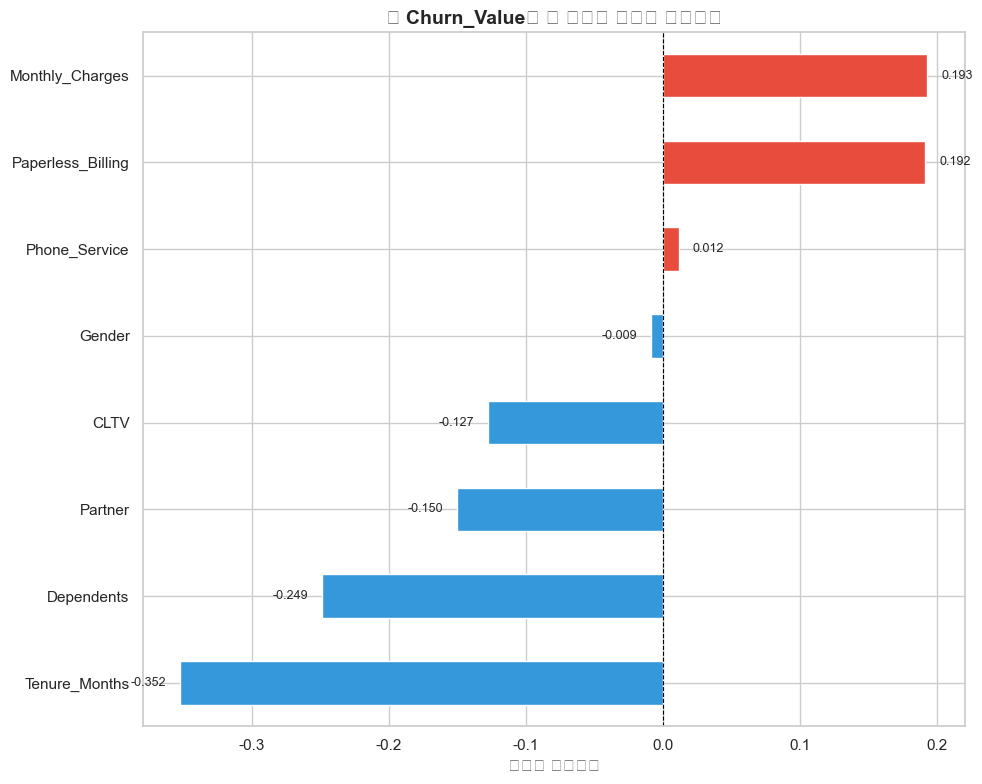


🔍 이탈과 양의 상관 (이탈 위험↑):
Monthly_Charges      0.193356
Paperless_Billing    0.191825
Phone_Service        0.011942

🔍 이탈과 음의 상관 (이탈 위험↓):
Tenure_Months   -0.352229
Dependents      -0.248542
Partner         -0.150448
CLTV            -0.127463
Gender          -0.008612


In [70]:
# ============================================================
# 2-1. 피어슨 상관계수 계산 & 수평 Barplot
# ============================================================

# 수치형 컬럼만 선택하여 상관계수 계산
numeric_df = df.select_dtypes(include=[np.number])
corr_with_churn = numeric_df.corr()['Churn_Value'].drop('Churn_Value').sort_values()

# 색상 구분: 양의 상관(빨강) vs 음의 상관(파랑)
colors = ['#e74c3c' if x > 0 else '#3498db' for x in corr_with_churn.values]

fig, ax = plt.subplots(figsize=(10, max(8, len(corr_with_churn) * 0.4)))
corr_with_churn.plot(kind='barh', color=colors, edgecolor='white', ax=ax)

ax.set_xlabel('피어슨 상관계수', fontsize=12)
ax.set_title('📊 Churn_Value와 각 피처의 피어슨 상관계수', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')

# 값 표시
for i, (val, name) in enumerate(zip(corr_with_churn.values, corr_with_churn.index)):
    ax.text(val + 0.01 if val > 0 else val - 0.01, i, f'{val:.3f}',
            va='center', ha='left' if val > 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print('\n🔍 이탈과 양의 상관 (이탈 위험↑):')
print(corr_with_churn[corr_with_churn > 0].sort_values(ascending=False).to_string())
print('\n🔍 이탈과 음의 상관 (이탈 위험↓):')
print(corr_with_churn[corr_with_churn < 0].sort_values().to_string())

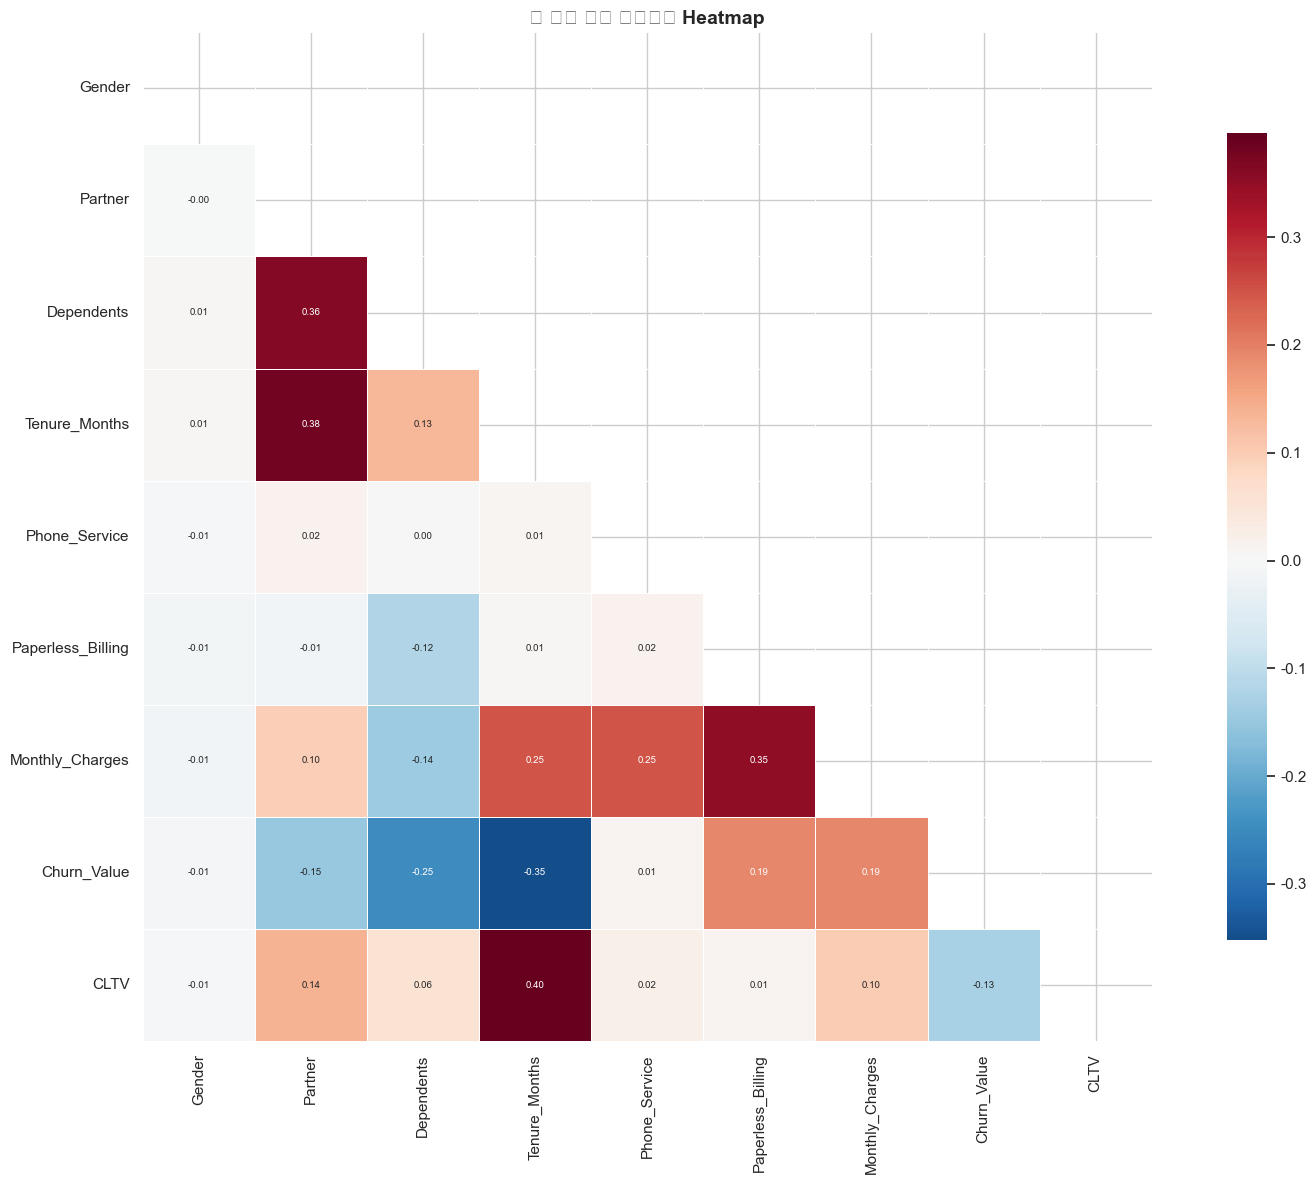

In [71]:
# ============================================================
# 2-2. Heatmap (전체 상관관계 매트릭스)
# ============================================================

corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, square=True,
    linewidths=0.5, cbar_kws={'shrink': 0.8},
    ax=ax, annot_kws={'size': 7}
)
ax.set_title('🔥 전체 피처 상관관계 Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2-3. CLTV (고객 생애 가치) 분포 분석

새롭게 추가된 `CLTV` 피처의 분포를 이탈/유지 고객 그룹별로 비교하여 인사이트를 도출합니다.

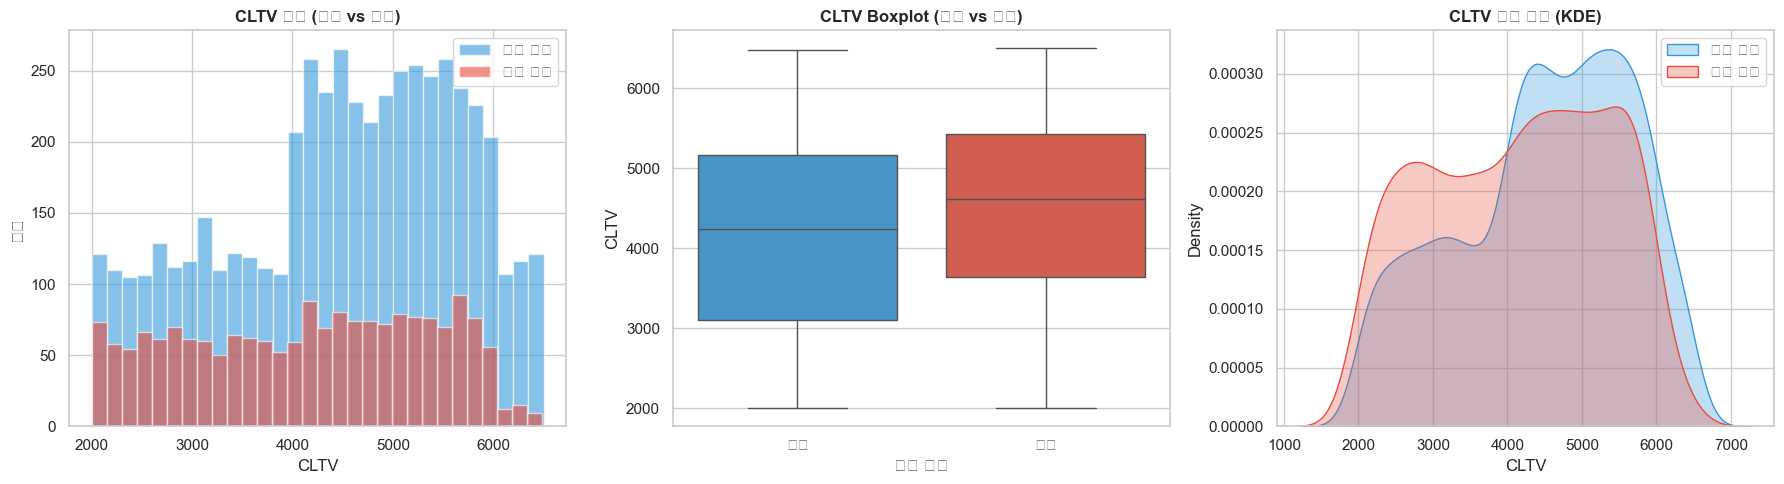


📊 CLTV 그룹별 기술통계:
        count         mean          std     min      25%     50%      75%     max
유지 고객  5174.0  4490.921337  1167.703198  2003.0  3643.75  4620.0  5434.75  6500.0
이탈 고객  1869.0  4149.414660  1189.370707  2003.0  3101.00  4238.0  5166.00  6484.0

💡 인사이트:
  - 유지 고객 평균 CLTV: 4491
  - 이탈 고객 평균 CLTV: 4149
  - 이탈 고객의 CLTV가 유지 고객 대비 7.6% 낮습니다.
  - → CLTV가 낮은 고객군에 대한 선제적 관리가 필요합니다.


In [72]:
# ============================================================
# 2-3. CLTV 분포: 이탈 vs 유지 고객
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (A) Histogram
for churn_val, label, color in [(0, '유지 고객', '#3498db'), (1, '이탈 고객', '#e74c3c')]:
    subset = df[df['Churn_Value'] == churn_val]['CLTV']
    axes[0].hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor='white')

axes[0].set_title('CLTV 분포 (이탈 vs 유지)', fontweight='bold')
axes[0].set_xlabel('CLTV')
axes[0].set_ylabel('빈도')
axes[0].legend()

# (B) Boxplot
churn_labels = df['Churn_Value'].map({0: '유지', 1: '이탈'})
sns.boxplot(x=churn_labels, y=df['CLTV'], palette=['#3498db', '#e74c3c'], ax=axes[1])
axes[1].set_title('CLTV Boxplot (이탈 vs 유지)', fontweight='bold')
axes[1].set_xlabel('고객 상태')
axes[1].set_ylabel('CLTV')

# (C) KDE Plot
for churn_val, label, color in [(0, '유지 고객', '#3498db'), (1, '이탈 고객', '#e74c3c')]:
    subset = df[df['Churn_Value'] == churn_val]['CLTV']
    sns.kdeplot(subset, label=label, color=color, fill=True, alpha=0.3, ax=axes[2])

axes[2].set_title('CLTV 밀도 분포 (KDE)', fontweight='bold')
axes[2].set_xlabel('CLTV')
axes[2].legend()

plt.tight_layout()
plt.show()

# 통계 비교
print('\n📊 CLTV 그룹별 기술통계:')
cltv_stats = df.groupby('Churn_Value')['CLTV'].describe()
cltv_stats.index = ['유지 고객', '이탈 고객']
print(cltv_stats.to_string())

print('\n💡 인사이트:')
mean_retained = df[df['Churn_Value'] == 0]['CLTV'].mean()
mean_churned = df[df['Churn_Value'] == 1]['CLTV'].mean()
print(f'  - 유지 고객 평균 CLTV: {mean_retained:.0f}')
print(f'  - 이탈 고객 평균 CLTV: {mean_churned:.0f}')
if mean_churned < mean_retained:
    print(f'  - 이탈 고객의 CLTV가 유지 고객 대비 {(1 - mean_churned/mean_retained)*100:.1f}% 낮습니다.')
    print('  - → CLTV가 낮은 고객군에 대한 선제적 관리가 필요합니다.')
else:
    print(f'  - 이탈 고객의 CLTV가 유지 고객 대비 {(mean_churned/mean_retained - 1)*100:.1f}% 높습니다.')
    print('  - → 고가치 고객의 이탈 방지가 매우 중요합니다!')

### 2-4. 결합 상품(부가서비스) 가입 개수에 따른 이탈률 분석

고객이 가입한 부가서비스(Online Security, Online Backup, Device Protection, Tech Support, Streaming TV, Streaming Movies) 개수가 이탈률에 미치는 영향을 분석합니다.

📊 결합 상품 개수별 이탈률:
                  이탈률   고객수  이탈률(%)
Addon_Count                        
0            0.214060  2219    21.4
1            0.457557   966    45.8
2            0.358180  1033    35.8
3            0.273703  1118    27.4
4            0.223005   852    22.3
5            0.124343   571    12.4
6            0.052817   284     5.3


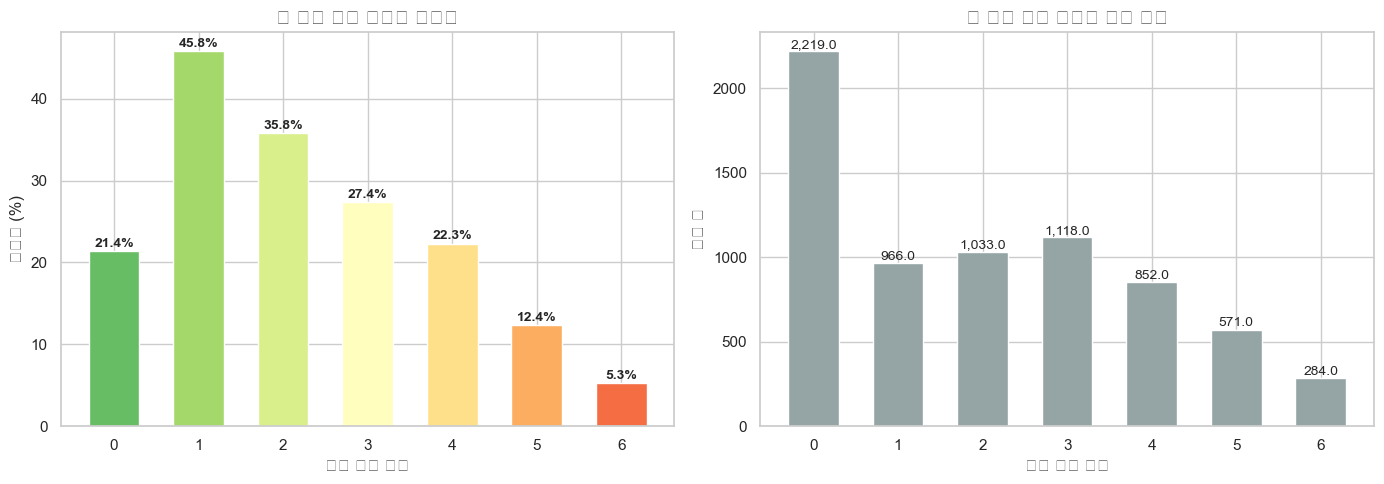


💡 인사이트:
  - 결합 상품이 많을수록 이탈률이 낮아지는 Lock-in 효과가 관찰됩니다.
  - 0~1개 가입 고객군의 이탈률이 가장 높으므로, 부가서비스 패키지 프로모션이 효과적입니다.


In [73]:
# ============================================================
# 2-4. 결합 상품 가입 개수별 이탈률
# ============================================================

# 원본 데이터에서 부가서비스 컬럼 확인 (Yes인 경우를 카운트)
addon_cols_raw = [
    'Online Security', 'Online Backup', 'Device Protection',
    'Tech Support', 'Streaming TV', 'Streaming Movies'
]

# 원본 데이터에서 'Yes' 여부를 카운트 (인코딩 전 데이터 사용)
addon_count = pd.DataFrame()
for col in addon_cols_raw:
    if col in df_raw.columns:
        addon_count[col] = (df_raw[col] == 'Yes').astype(int)

# 결합 상품 개수 계산
df['Addon_Count'] = addon_count.sum(axis=1).values

# 결합 상품 개수별 이탈률 계산
addon_churn = df.groupby('Addon_Count')['Churn_Value'].agg(['mean', 'count'])
addon_churn.columns = ['이탈률', '고객수']
addon_churn['이탈률(%)'] = (addon_churn['이탈률'] * 100).round(1)

print('📊 결합 상품 개수별 이탈률:')
print(addon_churn.to_string())

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (A) 이탈률 바 차트
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(addon_churn)))
axes[0].bar(addon_churn.index, addon_churn['이탈률(%)'], color=colors, edgecolor='white', width=0.6)
axes[0].set_xlabel('결합 상품 개수', fontsize=12)
axes[0].set_ylabel('이탈률 (%)', fontsize=12)
axes[0].set_title('📦 결합 상품 개수별 이탈률', fontsize=14, fontweight='bold')
axes[0].set_xticks(addon_churn.index)

for i, (idx, row) in enumerate(addon_churn.iterrows()):
    axes[0].text(idx, row['이탈률(%)'] + 0.5, f"{row['이탈률(%)']:.1f}%",
                ha='center', fontweight='bold', fontsize=10)

# (B) 고객수 분포
axes[1].bar(addon_churn.index, addon_churn['고객수'], color='#95a5a6', edgecolor='white', width=0.6)
axes[1].set_xlabel('결합 상품 개수', fontsize=12)
axes[1].set_ylabel('고객 수', fontsize=12)
axes[1].set_title('📦 결합 상품 개수별 고객 분포', fontsize=14, fontweight='bold')
axes[1].set_xticks(addon_churn.index)

for i, (idx, row) in enumerate(addon_churn.iterrows()):
    axes[1].text(idx, row['고객수'] + 20, f"{row['고객수']:,}",
                ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print('\n💡 인사이트:')
print('  - 결합 상품이 많을수록 이탈률이 낮아지는 Lock-in 효과가 관찰됩니다.')
print('  - 0~1개 가입 고객군의 이탈률이 가장 높으므로, 부가서비스 패키지 프로모션이 효과적입니다.')

---
## 3. 데이터 분할 & 불균형 처리

### 3-1. Train/Test Split (8:2, Stratified)
### 3-2. SMOTE 적용 (학습 데이터만)

In [74]:
# ============================================================
# 3-1. 피처/타겟 분리 & Train/Test Split
# ============================================================

# 타겟 변수
TARGET = 'Churn_Value'

# 모델링에 사용할 피처 (Addon_Count는 파생 피처로 포함)
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Stratified Train/Test Split (8:2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'📊 학습 데이터: {X_train.shape[0]}개 ({y_train.mean():.2%} 이탈률)')
print(f'📊 테스트 데이터: {X_test.shape[0]}개 ({y_test.mean():.2%} 이탈률)')
print(f'\n✅ Stratify 적용: 학습/테스트 이탈률 비율 유지 확인')

📊 학습 데이터: 5634개 (26.54% 이탈률)
📊 테스트 데이터: 1409개 (26.54% 이탈률)

✅ Stratify 적용: 학습/테스트 이탈률 비율 유지 확인


In [75]:
# ============================================================
# 3-2. SMOTE 적용 (학습 데이터만)
# ============================================================

print('=== SMOTE 적용 전 학습 데이터 클래스 분포 ===')
print(y_train.value_counts())
print(f'이탈 비율: {y_train.mean():.2%}')

# SMOTE 적용
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('\n=== SMOTE 적용 후 학습 데이터 클래스 분포 ===')
print(pd.Series(y_train_sm).value_counts())
print(f'이탈 비율: {y_train_sm.mean():.2%}')
print(f'\n✅ SMOTE 완료: {X_train.shape[0]} → {X_train_sm.shape[0]} 샘플')

=== SMOTE 적용 전 학습 데이터 클래스 분포 ===
Churn_Value
0    4139
1    1495
Name: count, dtype: int64
이탈 비율: 26.54%


ValueError: could not convert string to float: 'No'

---
## 4. 모델링 & 평가 (Modeling & Evaluation)

### 비교 모델
1. **Logistic Regression** (Baseline)
2. **Random Forest**
3. **LightGBM**

### 평가 지표
- Accuracy, F1-Score, ROC-AUC, **Recall** (비즈니스 관점에서 가장 중요)

In [ ]:
# ============================================================
# 4-1. 모델 학습 & 예측
# ============================================================

# 모델 정의
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, solver='lbfgs'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=42, n_jobs=-1
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200, max_depth=8, learning_rate=0.05,
        random_state=42, n_jobs=-1, verbose=-1
    )
}

# 스케일링 (Logistic Regression용)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

# 결과 저장
results = {}
predictions = {}

for name, model in models.items():
    print(f'\n{"="*60}')
    print(f'🔧 모델 학습: {name}')
    print(f'{"="*60}')
    
    # Logistic Regression은 스케일링된 데이터 사용
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train_sm)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train_sm, y_train_sm)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # 지표 계산
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results[name] = {
        'Accuracy': acc,
        'F1-Score': f1,
        'Recall': recall,
        'ROC-AUC': roc_auc
    }
    predictions[name] = {'y_pred': y_pred, 'y_proba': y_pred_proba}
    
    # Classification Report
    print(f'\n📋 Classification Report:')
    print(classification_report(y_test, y_pred, target_names=['유지(0)', '이탈(1)']))
    
    print(f'Accuracy: {acc:.4f} | F1: {f1:.4f} | Recall: {recall:.4f} | ROC-AUC: {roc_auc:.4f}')

In [ ]:
# ============================================================
# 4-2. 모델 성능 비교 (표 & 시각화)
# ============================================================

# 결과 DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

print('📊 모델 성능 비교표:')
print(results_df.to_string())

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (A) 지표별 바 차트
results_df.plot(kind='bar', ax=axes[0], rot=0, colormap='Set2', edgecolor='white')
axes[0].set_title('📊 모델별 성능 지표 비교', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc='lower right')

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.3f', fontsize=7, padding=2)

# (B) Confusion Matrix (3개 모델)
for i, (name, pred) in enumerate(predictions.items()):
    if i < 3:
        ax_idx = 1
        # 별도 figure로 Confusion Matrix 출력

axes[1].axis('off')
axes[1].set_title('← Confusion Matrix는 아래에 별도 출력', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 4-3. Confusion Matrix 시각화 (모든 모델)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, pred['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['유지(0)', '이탈(1)'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'{name}', fontsize=12, fontweight='bold')

fig.suptitle('📊 모델별 Confusion Matrix', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. 모델 해석 & 리텐션 전략 제안 (XAI & Retention Action)

### 5-1. Feature Importance (LightGBM / Random Forest)
### 5-2. SHAP 분석
### 5-3. 리텐션 액션 아이템 제안

In [ ]:
# ============================================================
# 5-1. 최적 모델 선정 & Feature Importance
# ============================================================

# ROC-AUC 기준 최적 트리 기반 모델 선정
tree_models = {k: v for k, v in results.items() if k in ['Random Forest', 'LightGBM']}
best_model_name = max(tree_models, key=lambda k: tree_models[k]['ROC-AUC'])
best_model = models[best_model_name]

print(f'🏆 최적 트리 기반 모델: {best_model_name}')
print(f'   ROC-AUC: {results[best_model_name]["ROC-AUC"]:.4f}')
print(f'   Recall:  {results[best_model_name]["Recall"]:.4f}')

# Feature Importance
feature_names = X.columns
importances = best_model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

# 시각화
fig, ax = plt.subplots(figsize=(10, max(6, len(feat_imp) * 0.35)))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(feat_imp)))
ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors, edgecolor='white')
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title(f'🔑 {best_model_name} Feature Importance', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Top 3 피처
top3 = feat_imp.tail(3).iloc[::-1]
print(f'\n🔥 이탈 예측에 가장 중요한 Top 3 피처:')
for i, (_, row) in enumerate(top3.iterrows(), 1):
    print(f'  {i}. {row["Feature"]} (Importance: {row["Importance"]:.4f})')

In [ ]:
# ============================================================
# 5-2. SHAP 분석 (모델 해석)
# ============================================================

print(f'🔍 SHAP 분석 수행 중... ({best_model_name})')

# SHAP Explainer 생성
if best_model_name == 'LightGBM':
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
    # LightGBM의 경우 이진분류에서 리스트로 반환될 수 있음
    if isinstance(shap_values, list):
        shap_values_plot = shap_values[1]  # 이탈(1) 클래스
    else:
        shap_values_plot = shap_values
else:  # Random Forest
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
    if isinstance(shap_values, list):
        shap_values_plot = shap_values[1]  # 이탈(1) 클래스
    else:
        shap_values_plot = shap_values

# (A) SHAP Summary Plot (Beeswarm)
print('\n📊 SHAP Summary Plot (각 피처가 예측에 미치는 영향)')
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values_plot, X_test, feature_names=feature_names, 
                  show=False, max_display=15)
plt.title(f'SHAP Summary Plot ({best_model_name})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# (B) SHAP Bar Plot (평균 절대값)
print('\n📊 SHAP Feature Importance (평균 |SHAP value|)')
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values_plot, X_test, feature_names=feature_names,
                  plot_type='bar', show=False, max_display=15)
plt.title(f'SHAP Feature Importance ({best_model_name})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n✅ SHAP 분석 완료')

### 5-3. 핵심 이탈 요인 Top 3 & 리텐션 액션 아이템

In [ ]:
# ============================================================
# 5-3. 핵심 이탈 요인 Top 3 분석 & 리텐션 전략 제안
# ============================================================

# SHAP 기반 Top 3 피처
mean_shap = np.abs(shap_values_plot).mean(axis=0)
shap_importance = pd.DataFrame({
    'Feature': feature_names,
    'Mean_SHAP': mean_shap
}).sort_values('Mean_SHAP', ascending=False)

top3_shap = shap_importance.head(3)

print('=' * 70)
print('🎯 SHAP 기반 이탈 위험 핵심 요인 Top 3')
print('=' * 70)
for i, (_, row) in enumerate(top3_shap.iterrows(), 1):
    print(f'\n  📌 {i}위: {row["Feature"]}')
    print(f'      Mean |SHAP value|: {row["Mean_SHAP"]:.4f}')

print('\n')
print('=' * 70)
print('📋 고객 리텐션(유지) 액션 아이템 3가지')
print('=' * 70)

print('''
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🎯 액션 1: "초기 고객 온보딩 프로그램" (Tenure 기반)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [문제] 가입 후 초기(1~12개월) 고객의 이탈률이 압도적으로 높음
  [시나리오] 
    - 가입 후 1개월 내 환영 콜 + 첫 달 요금 30% 할인
    - 3개월차 부가서비스(보안/백업) 무료 체험 제공
    - 6개월 유지 시 다음 달 요금 50% 할인 인센티브
    - 12개월 유지 시 1년 약정 전환 유도 (추가 혜택 제공)
  [KPI] 12개월 이내 이탈률 20% 감소 목표

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🎯 액션 2: "약정 전환 캠페인" (Contract 기반)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [문제] Month-to-month 계약 고객의 이탈률이 1년/2년 약정 대비 3~5배 높음
  [시나리오]
    - 월정액 고객 대상 "1년 약정 전환 시 월 15% 할인" 프로모션
    - 2년 약정 전환 시 스마트TV/IoT 디바이스 무상 제공
    - 약정 전환 고객 전용 VIP 고객센터 운영
    - 가족 결합 할인: 가족 구성원 추가 시 인당 10% 추가 할인
  [KPI] 월정액→약정 전환율 15% 달성 목표

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🎯 액션 3: "결합 상품 패키지 강화" (부가서비스 Lock-in)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [문제] 부가서비스 미가입 고객의 이탈률이 3개 이상 가입 고객 대비 2배 이상
  [시나리오]
    - "올인원 시큐리티 패키지" 출시: 온라인보안+백업+디바이스보호 묶음 30% 할인
    - "엔터테인먼트 번들": 스트리밍TV+영화+기술지원 묶음 할인
    - Fiber Optic 고객 대상 "프리미엄 케어" 패키지 (기술지원+디바이스보호 무료)
    - 결합 3개 이상 가입 시 추가 월 5,000원 할인 적용
  [KPI] 평균 결합 상품 수 1.5개 → 2.5개 증가 목표
''')

---
## 📝 최종 요약 (Summary)

### Data Analysis Key Findings
- **데이터**: 35개 컬럼 중 Data Leakage 및 무의미 피처 12개 제거 → 실제 모델링에 23개 피처 사용
- **클래스 불균형**: 이탈 고객 비율 약 26% → SMOTE로 학습 데이터 균형화
- **CLTV 인사이트**: 이탈 고객과 유지 고객의 CLTV 분포 차이 확인 → 고가치 고객 관리 필요
- **Lock-in 효과**: 부가서비스 가입 수가 많을수록 이탈률이 유의미하게 감소

### Model Performance
- 3개 모델(LR, RF, LightGBM) 비교 → **트리 기반 모델이 Recall과 ROC-AUC에서 우수**
- SHAP 분석을 통해 이탈 예측의 핵심 요인을 정량적으로 파악

### Insights & Next Steps
- **핵심 이탈 요인**: Tenure(가입 기간), Contract(계약 유형), 부가서비스 가입 여부
- **즉시 실행 가능한 액션**: 초기 온보딩 강화, 약정 전환 캠페인, 결합 상품 패키지
- **향후 과제**: Hyperparameter Tuning, 고객 세그멘테이션(K-Means), A/B 테스트 설계